<a href="https://colab.research.google.com/github/ethxng/ACL-Tear-Image-Classifer/blob/main/mri_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pickle
import os

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patch
from torch.utils.data import TensorDataset, DataLoader, ConcatDataset
from torchvision import models, transforms, datasets
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from tqdm import tqdm
import cv2

In [ ]:
# directory where the volumetric data is located
volumetric_data_dir = '/content/drive/MyDrive/mri_db/volumetric_data'

# path to metadata csv file
metadata_csv_path = '/content/drive/MyDrive/mri_db/metadata.csv'

# names=True loads the interprets the first row of csv file as column names
# 'i4' = 4 byte signed integer, 'U20' = unicode max 20 char string
metadata = np.genfromtxt(metadata_csv_path, delimiter=',', names=True,
    dtype='i4,i4,i4,i4,i4,i4,i4,i4,i4,i4,U20')

print('Column names:')
print(metadata.dtype.names)
print(len(np.unique(metadata['examId'])))

Column names:
('examId', 'seriesNo', 'aclDiagnosis', 'kneeLR', 'roiX', 'roiY', 'roiZ', 'roiHeight', 'roiWidth', 'roiDepth', 'volumeFilename')
909


# Viewing the input as 2D images


Shape of volume "/content/drive/MyDrive/mri_db/volumetric_data/1001888-5.pck": (32, 320, 320)
Slice 15:


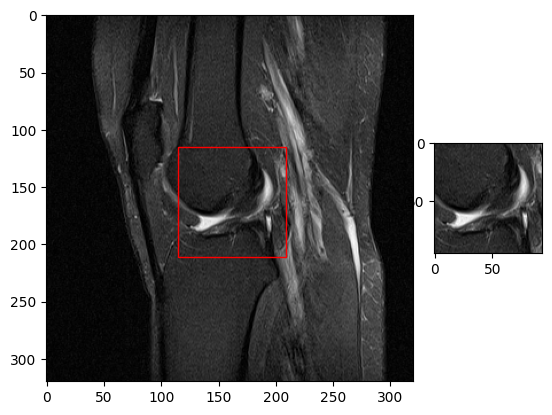

Slice 16:


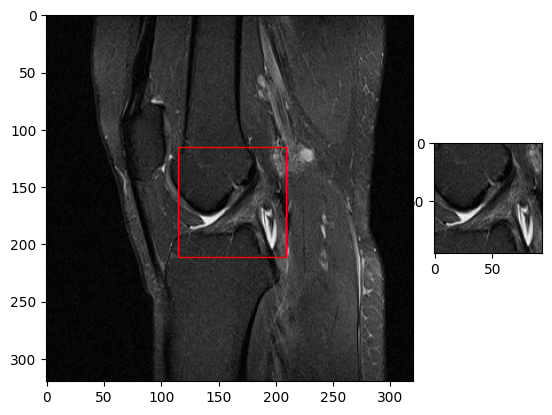

Slice 17:


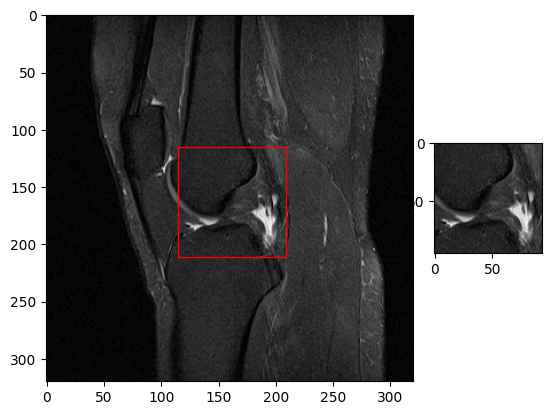

In [ ]:
# Select all rows where examID == 502889
exams = metadata[metadata['examId'] == 1001888]

for exam in exams:
    vol_data_file = exam['volumeFilename']

    vol_data_path = os.path.join(volumetric_data_dir, vol_data_file)

    # Load data from file
    with open(vol_data_path, 'rb') as file_handler: # Must use 'rb' as the data is binary
        volumetric_data = pickle.load(file_handler)

    print('\nShape of volume "%s":' % vol_data_path, volumetric_data.shape)

    # Get all roi slices from volume
    z_start = exam['roiZ']
    depth = exam['roiDepth']

    for z in range(z_start, z_start + depth):
        print(f"Slice {z}:")
        slice = volumetric_data[z, :, :]
        # Get roi dimensions
        x, y, w, h = [exam[attr] for attr in ['roiX', 'roiY', 'roiWidth', 'roiHeight']]

        # Extract ROI (will use this as input, stack all 3 slices together to make a 3 channel input)
        roi = slice[y:y+h, x:x+w]

        # Plot slice and roi
        figure = plt.figure()
        plot = plt.subplot2grid((1, 4), (0, 0), 1, 3) # This makes the slice plot larger than roi plot
        plot.add_patch(patch.Rectangle((x, y), w, h, fill=None, color='red'))
        plot.imshow(slice, cmap='gray')
        plot = plt.subplot2grid((1, 4), (0, 3), 1, 1)
        plot.imshow(roi, cmap='gray')

        plt.show()


Shape of volume "/content/drive/MyDrive/mri_db/volumetric_data/1001888-5.pck": (32, 320, 320)
There are 32 slices in this MRI image


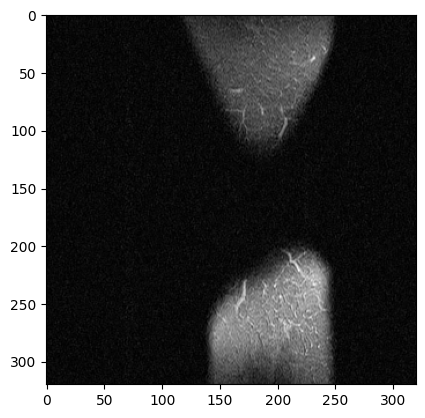

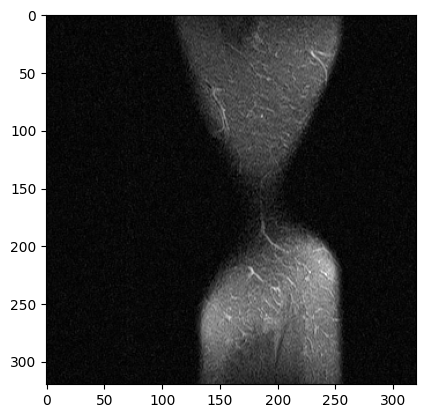

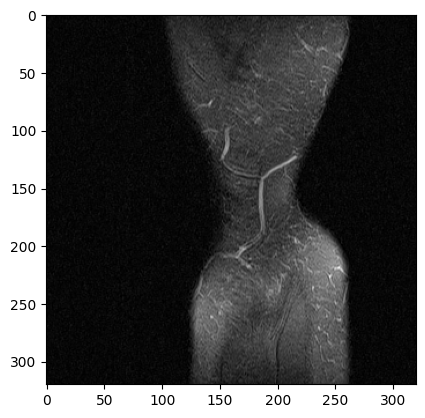

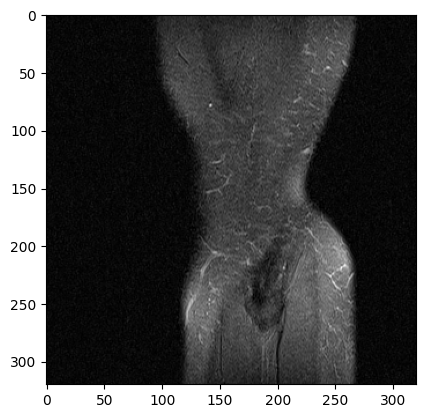

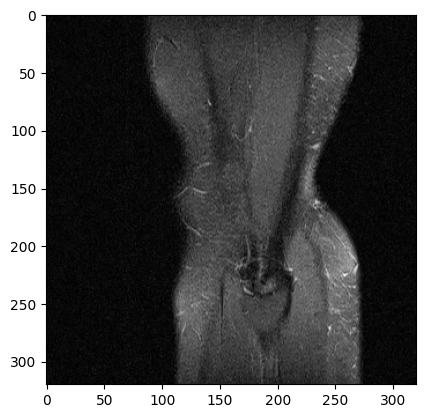

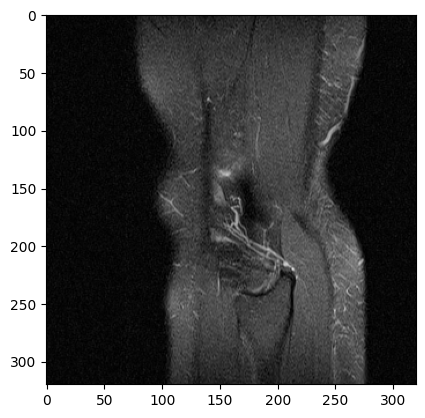

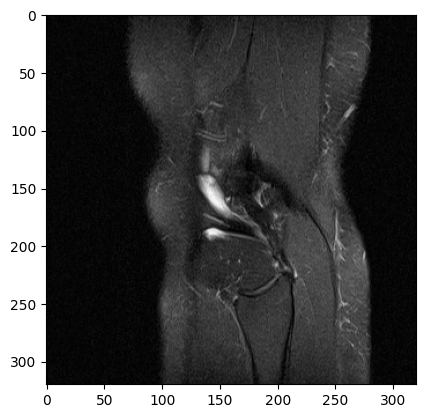

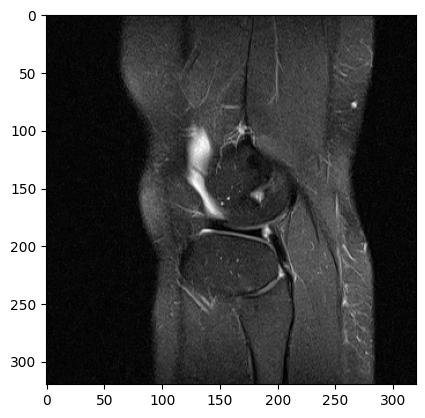

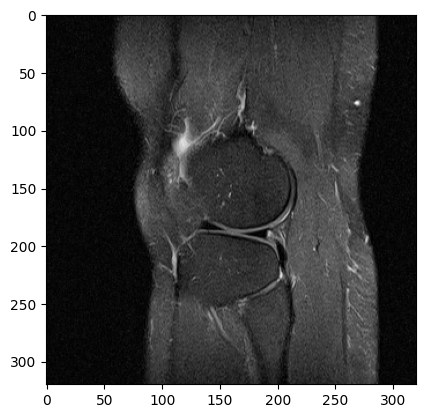

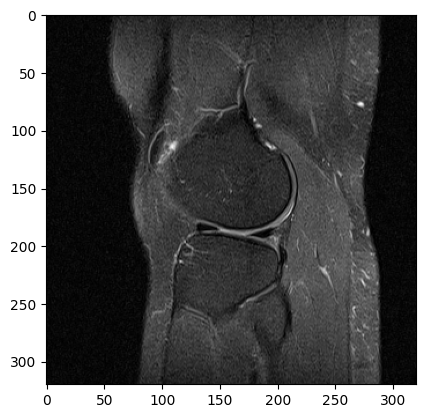

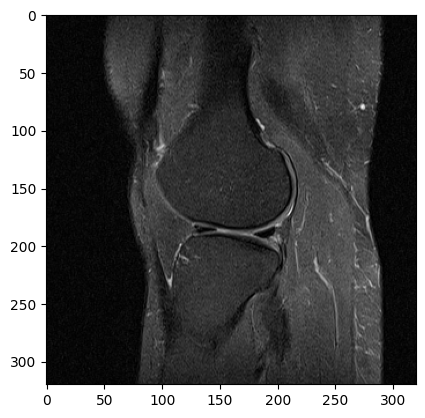

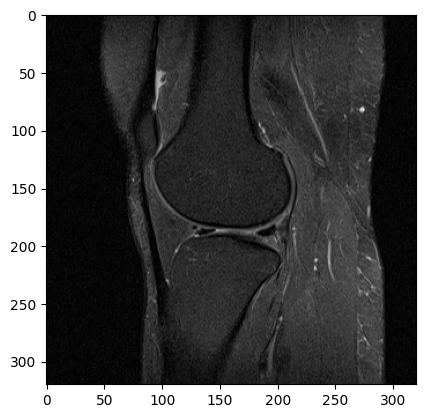

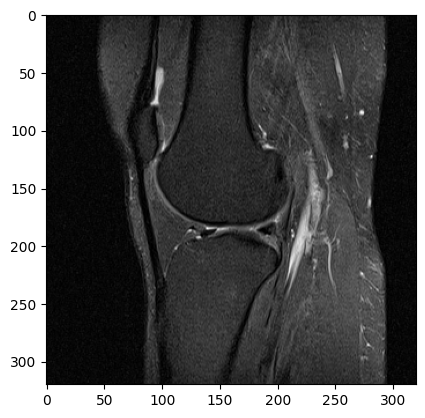

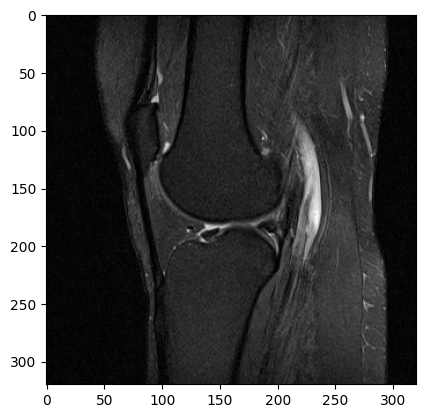

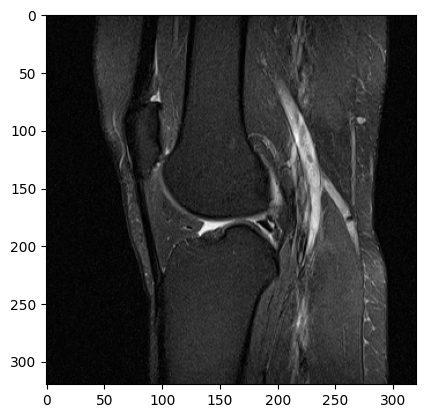

tensor([[[-1.0902, -0.9708, -1.0739,  ..., -0.9685, -0.9916, -0.8872],
         [-1.0997, -0.9521, -1.0418,  ..., -1.1220, -1.0601, -0.9236],
         [-0.9598, -1.0527, -1.0903,  ..., -1.0686, -1.0481, -1.1053],
         ...,
         [-0.9447, -0.9480, -1.1044,  ..., -0.9575, -1.0632, -0.9954],
         [-1.0896, -1.0121, -0.8654,  ..., -1.0861, -0.9349, -0.8517],
         [-1.0278, -0.9353, -0.9940,  ..., -0.9725, -1.0614, -0.9344]]])
torch.Size([1, 224, 224])


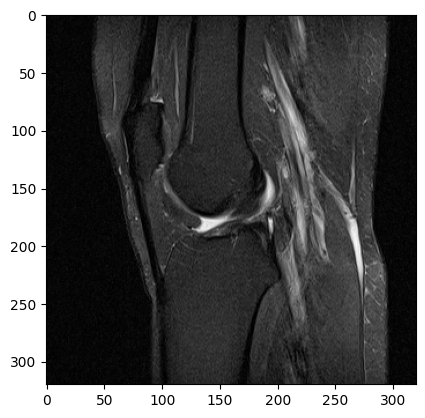

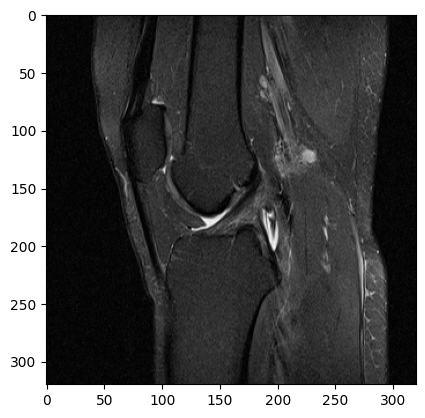

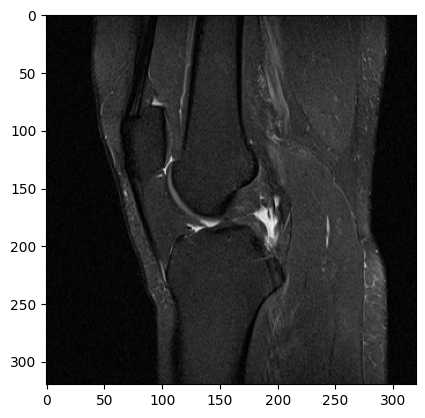

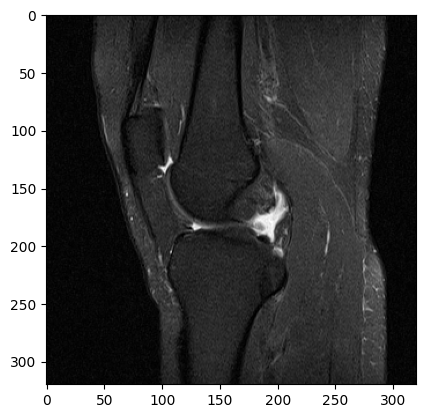

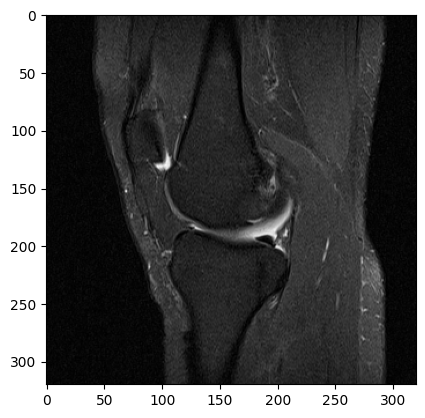

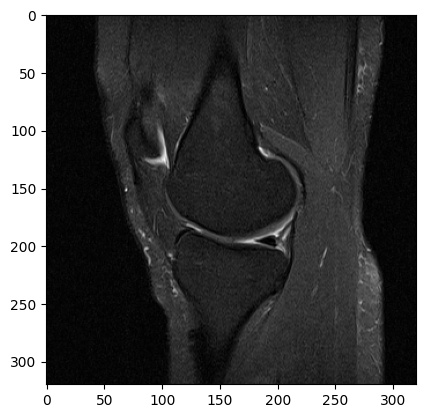

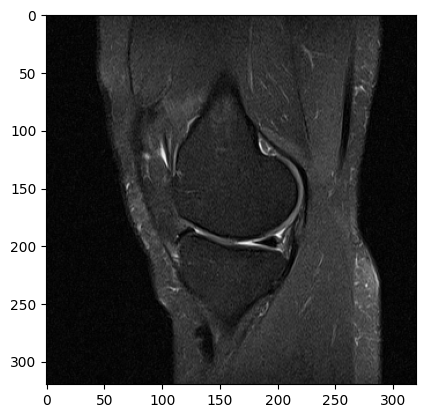

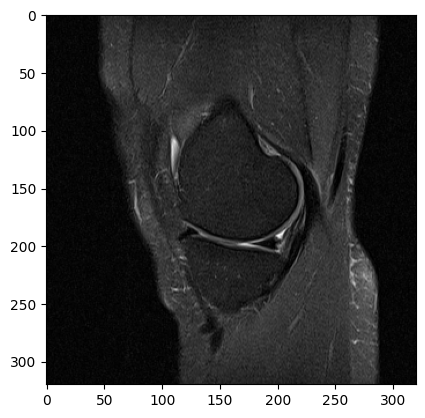

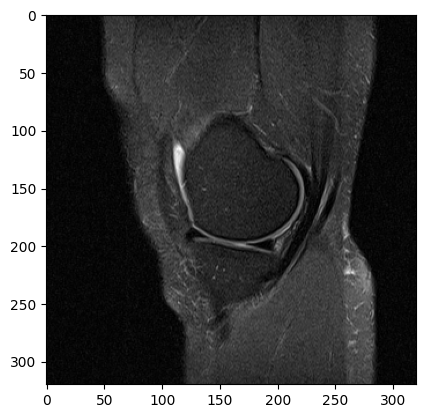

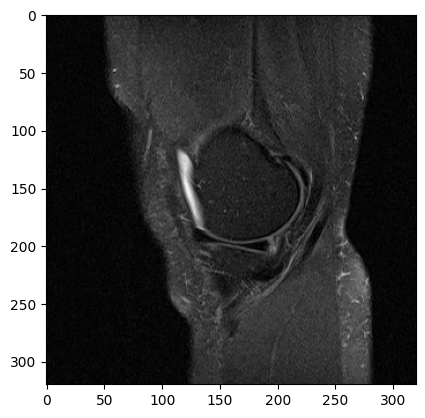

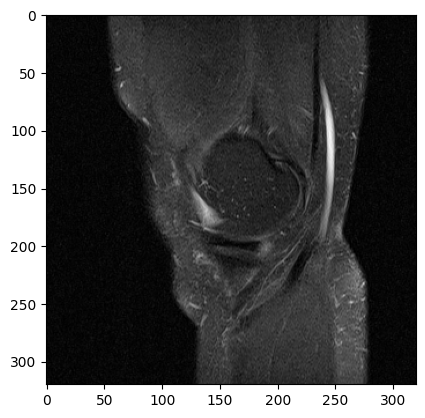

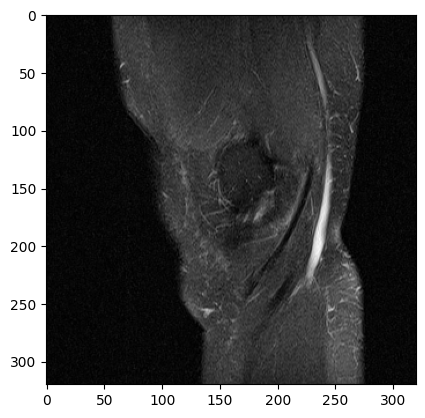

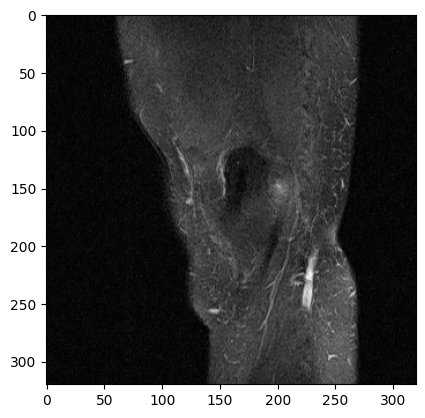

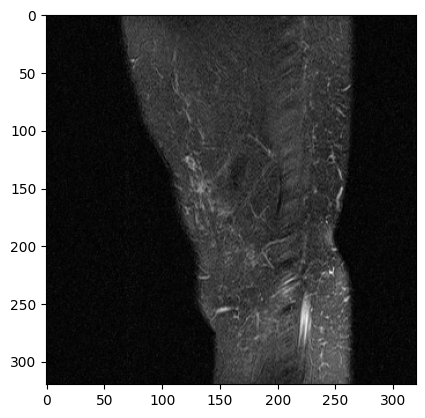

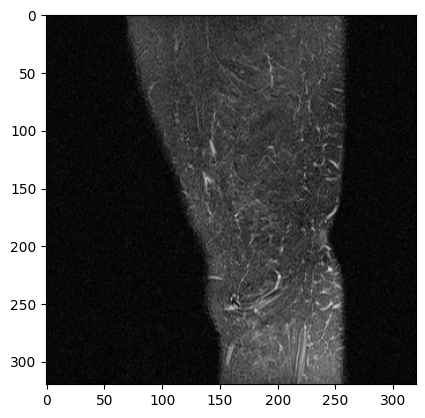

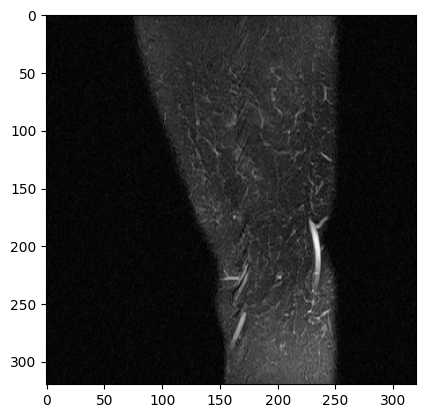

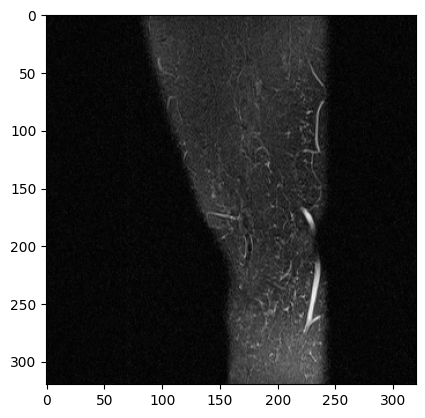

In [ ]:
# Select all rows where examID == 502889
exams = metadata[metadata['examId'] == 1001888]
preprocessor = MRIPreprocessor()
for exam in exams:
    vol_data_file = exam['volumeFilename']

    vol_data_path = os.path.join(volumetric_data_dir, vol_data_file)

    # Load data from file
    with open(vol_data_path, 'rb') as file_handler: # Must use 'rb' as the data is binary
        volumetric_data = pickle.load(file_handler)

    print('\nShape of volume "%s":' % vol_data_path, volumetric_data.shape)
    print(f"There are {volumetric_data.shape[0]} slices in this MRI image")
    # Get all roi slices from volume
    z_start = exam['roiZ']
    depth = exam['roiDepth']

    for z in range(volumetric_data.shape[0]):

        slice = volumetric_data[z, :, :]
        if z == 15:
          processed_slice = preprocessor(slice)
          print(processed_slice)
          print(processed_slice.shape)
        # Plot slice
        figure = plt.figure()
        plt.imshow(slice, cmap='gray')
        plt.show()

# Data pre-processing

In [ ]:
metadata = pd.read_csv(metadata_csv_path) # 0 = healthy, 1 = partially torn, 2 = fully torn (can combine 1 and 2)
metadata['aclDiagnosis'].value_counts()

,count
aclDiagnosis,
0,690
1,172
2,55


In [ ]:
# grab all examId
examIds = metadata['examId']

In [ ]:
class MRIPreprocessor:
    def __init__(self, output_size=(224, 224)):
        self.output_size = output_size

    def __call__(self, roi):
        # Convert to float32
        roi = roi.astype(np.float32)

        # Z-score normalization (mean=0, std=1)
        mean = np.mean(roi)
        std = np.std(roi)
        roi = (roi - mean) / (std + 1e-8)  # Add epsilon to avoid division by zero

        # Convert to tensor and add dimensions
        x = torch.from_numpy(roi).unsqueeze(0).unsqueeze(0)

        # Resize
        resized = F.interpolate(x, size=self.output_size,
                               mode="bilinear", align_corners=False)

        return resized.squeeze(0)  # Shape: (1, 224, 224)

In [ ]:
# preprocessor = MRIPreprocessor()

# all_images = []
# all_labels = []

# for id in examIds:
#   exams = metadata[metadata['examId'] == id]

#   for index, exam in exams.iterrows(): # unpack the tuple into index and Series
#     vol_data_file = exam['volumeFilename'] # Access data from the Series

#     vol_data_path = os.path.join(volumetric_data_dir, vol_data_file)

#     # Load data from file
#     with open(vol_data_path, 'rb') as file_handler: # Must use 'rb' as the data is binary
#         volumetric_data = pickle.load(file_handler)

#     #print('\nShape of volume "%s":' % vol_data_path, volumetric_data.shape)

#     # Get all roi slices from volume
#     z_start = exam['roiZ']
#     depth = exam['roiDepth']
#     #print(depth)
#     for z in range(z_start, z_start + depth):

#         slice = volumetric_data[z, :, :]

#         # Get roi dimensions
#         x, y, w, h = [exam[attr] for attr in ['roiX', 'roiY', 'roiWidth', 'roiHeight']]

#         # Extract ROI (will use this as input, stack all 3 slices together to make a 3 channel input)
#         roi = slice[y:y+h, x:x+w]
#         processed_roi = preprocessor(roi)
#         all_images.append(processed_roi)
#         if exam['aclDiagnosis'] == 0:
#           all_labels.append(0)
#         else:
#           all_labels.append(1)

# # Stack into tensors
# images_tensor = torch.stack(all_images)  # (num_samples, 1, 224, 224)
# labels_tensor = torch.tensor(all_labels, dtype=torch.long)  # (num_samples,)

# # Create DataLoader
# dataset = TensorDataset(images_tensor, labels_tensor)
# dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)

In [ ]:
# write dataset to drive
# torch.save(dataset, '/content/drive/MyDrive/mri_db/preprocessed_acl_dataset.pt')

In [ ]:
# load in dataset
dataset = torch.load('/content/drive/MyDrive/mri_db/preprocessed_acl_dataset.pt', weights_only=False)

In [ ]:
len(dataset)

3146

In [ ]:
labels = dataset.tensors[1]  # Get the label tensor

train_val_indices, test_indices = train_test_split(
    range(len(dataset)), test_size=0.15, random_state=42, stratify=labels
)

# Get labels for train_val subset
train_val_labels = [labels[i] for i in train_val_indices]

# Second split: split train_val into train and val (70/15 of original)
train_indices, val_indices = train_test_split(
    train_val_indices, test_size=0.176, random_state=42, stratify=train_val_labels
)

# Create subsets
train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)
test_dataset = Subset(dataset, test_indices)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Split sizes: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

Split sizes: Train=2203, Val=471, Test=472


# Training models

## Resnet-50 (trainable weight only at Layer 4)


In [ ]:
# Training function with train/val loaders
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=10):
    train_acc_history, val_acc_history = [], []

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss, running_correct = 0.0, 0
        train_loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', position=0)

        for inputs, labels in train_loop:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_correct += (outputs.argmax(1) == labels).sum().item()

            train_loop.set_postfix({'Loss': f'{loss.item():.4f}'})

        train_acc = running_correct / len(train_loader.dataset)
        train_acc_history.append(train_acc)

        # Validation
        model.eval()
        val_correct = 0
        val_loop = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]', position=0)

        with torch.no_grad():
            for inputs, labels in val_loop:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)
        val_acc_history.append(val_acc)

        print(f'Epoch {epoch+1}: Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')
    return train_acc_history, val_acc_history

In [ ]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize ResNet-50
model = models.resnet50(weights='IMAGENET1K_V2')

# Modify first conv layer for 1-channel input (instead of weights in all 3 channels, it calculates the average into 1 channel)
original_conv1 = model.conv1
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
with torch.no_grad():
    model.conv1.weight[:, 0, :, :] = torch.mean(original_conv1.weight, dim=1)

# Modify final FC layer
num_classes = len(torch.unique(labels))
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# Freeze early layers, unfreeze later layers
for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True
# for param in model.fc.parameters():
#     param.requires_grad = True

# Loss and optimizer
criterion = nn.CrossEntropyLoss()

# this basically means: for each p in model.parameters(), only apply the optimizer to those that have requires_grad = True (so it only applies the optimizer to the layer than we have unfreezed)
optimizer = optim.Adam(filter(lambda p: p.requires_grad == True, model.parameters()), lr=0.001)

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 210MB/s]


In [ ]:
# Train the model
print("Starting training...")
train_acc_hist, val_acc_hist = train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=10)

# Print results
print(f"\nBest Training Accuracy: {max(train_acc_hist):.4f}")
print(f"Best Validation Accuracy: {max(val_acc_hist):.4f}")

Starting training...


Epoch 1/10 [Val]: 100%|██████████| 15/15 [00:01<00:00, 11.70it/s]


Epoch 1: Train Acc: 0.7844, Val Acc: 0.6794


Epoch 2/10 [Val]: 100%|██████████| 15/15 [00:01<00:00, 11.99it/s]


Epoch 2: Train Acc: 0.9233, Val Acc: 0.7495


...

Epoch 8: Train Acc: 0.9959, Val Acc: 0.8259


Epoch 9/10 [Val]: 100%|██████████| 15/15 [00:01<00:00, 11.39it/s]


Epoch 9: Train Acc: 0.9968, Val Acc: 0.8556


Epoch 10/10 [Val]: 100%|██████████| 15/15 [00:01<00:00, 11.40it/s]

Epoch 10: Train Acc: 0.9950, Val Acc: 0.8493

Best Training Accuracy: 0.9968
Best Validation Accuracy: 0.8556


In [ ]:
# Test function with test loader
def test_model(model, test_loader):
    model.eval()
    test_correct = 0
    test_loop = tqdm(test_loader, desc='Testing')

    with torch.no_grad():
        for inputs, labels in test_loop:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            test_correct += (outputs.argmax(1) == labels).sum().item()

    test_acc = test_correct / len(test_loader.dataset)
    return test_acc

## ConvNeXt model

In [ ]:
from torchvision.models import ConvNeXt_Base_Weights

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# init model

model2 = models.convnext_base(weights='IMAGENET1K_V1')

# modify first conv layer for 1-channel input
original_conv1 = model2.features[0][0]
new_conv1 = nn.Conv2d(1, 128, kernel_size=4, stride=4, padding=0, bias=False)
with torch.no_grad():
    new_conv1.weight[:, 0, :, :] = torch.mean(original_conv1.weight, dim=1)

model2.features[0][0] = new_conv1

# modify final FC layer to have only 2 outcomes (tear or no tear)
num_classes = len(torch.unique(labels))
model2.classifier[-1] = nn.Linear(model2.classifier[-1].in_features, num_classes)
model2 = model2.to(device)

# Freeze all layers
# for param in model2.parameters():
#     param.requires_grad = False

# train params in the FC and last 2 in the blocks
# for param in model2.classifier.parameters():
#     param.requires_grad = True
# for param in model2.features[6].parameters():
#     param.requires_grad = True
# for param in model2.features[7].parameters():
#     param.requires_grad = True

# loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad == True, model2.parameters()), lr=0.001)

Using device: cuda


In [ ]:
# Train the convNeXt model
print("Starting training using ConvNeXt...")
train_acc_hist, val_acc_hist = train_model(model2, train_loader, val_loader, optimizer, criterion, num_epochs=10)

# Print results
print(f"\nBest Training Accuracy: {max(train_acc_hist):.4f}")
print(f"Best Validation Accuracy: {max(val_acc_hist):.4f}")

Starting training using ConvNeXt...


Epoch 1/10 [Val]: 100%|██████████| 15/15 [00:04<00:00,  3.24it/s]


Epoch 1: Train Acc: 0.7481, Val Acc: 0.7537


Epoch 2/10 [Val]: 100%|██████████| 15/15 [00:04<00:00,  3.18it/s]


Epoch 2: Train Acc: 0.7549, Val Acc: 0.7537


...

Epoch 8: Train Acc: 0.7549, Val Acc: 0.7537


Epoch 9/10 [Val]: 100%|██████████| 15/15 [00:04<00:00,  3.14it/s]


Epoch 9: Train Acc: 0.7549, Val Acc: 0.7537


Epoch 10/10 [Val]: 100%|██████████| 15/15 [00:04<00:00,  3.15it/s]

Epoch 10: Train Acc: 0.7549, Val Acc: 0.7537

Best Training Accuracy: 0.7549
Best Validation Accuracy: 0.7537


# Using Grad-CAM on Resnet-50

In [ ]:
# --- Grad-CAM class ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x, class_idx=None):
        out = self.model(x)  # forward
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()

        self.model.zero_grad()
        out[:, class_idx].backward()

        # Grad-CAM weights
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        cam = F.relu(cam)
        cam = F.interpolate(cam, size=x.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min())  # normalize
        return cam

In [ ]:
original_imgs = np.load('/content/drive/MyDrive/mri_db/acl_mri_numpy.npy', allow_pickle=True)

In [ ]:
print(f'ACL Diagnosis: {original_imgs[3144][2]}')

ACL Diagnosis: 1


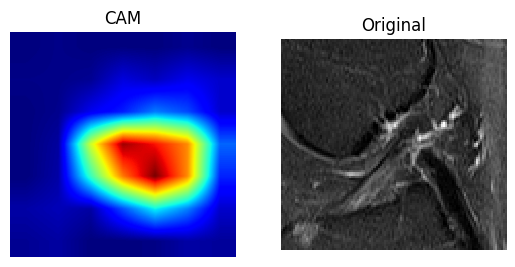

In [ ]:
model.eval()

# Grad-CAM instance on layer4
gradcam = GradCAM(model, model.layer4)

# normalize original image and change to tensor first
preprocessor = MRIPreprocessor()
image = original_imgs[3143][0]
img_tensor = preprocessor(image).to(device)

# Assume: img_tensor is [1,1,224,224], normalized input; orig_img is original numpy grayscale
input_tensor = img_tensor.unsqueeze(1)
cam = gradcam(input_tensor)

# Overlay on original
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
h, w = image.shape
heatmap_resized = cv2.resize(heatmap, (w, h))
overlay = 0.4 * heatmap_resized + np.repeat(image[..., None], 3, axis=2)

plt.subplot(1, 2, 1); plt.title("CAM"); plt.imshow(cam, cmap="jet"); plt.axis("off") # plot CAM
plt.subplot(1, 2, 2); plt.title("Original"); plt.imshow(image, cmap="gray", interpolation="nearest"); plt.axis("off") # plot the original image

plt.show()

# Part 2: MRI segmentation using U-net

## 2.0 Helper functions

In [ ]:
def create_mask_for_slice(slice_index, roi_params, slice_shape):
    """
    Create binary mask for a single 2D slice

    Args:
        slice_index: Current slice number (z-coordinate)
        roi_params: Dict with 'roiX', 'roiY', 'roiZ', 'roiHeight', 'roiWidth', 'roiDepth'
        slice_shape: (H, W) of the slice

    Returns:
        Binary mask (H, W) with 1s inside ROI, 0s outside
    """
    mask = np.zeros(slice_shape, dtype=np.float32)

    # Check if this slice contains ACL
    z_start = roi_params['roiZ']
    z_end = roi_params['roiZ'] + roi_params['roiDepth']

    if z_start <= slice_index < z_end:
        # This slice has ACL - fill the bounding box
        x_start = roi_params['roiX']
        x_end = roi_params['roiX'] + roi_params['roiWidth']
        y_start = roi_params['roiY']
        y_end = roi_params['roiY'] + roi_params['roiHeight']

        # Fill rectangle with 1s
        mask[y_start:y_end, x_start:x_end] = 1.0

    # Otherwise mask stays all zeros (no ACL in this slice)
    return mask

def z_score_normalize(slice_tensor, epsilon=1e-8):
    """Z-score normalization"""
    mean = slice_tensor.mean()
    std = slice_tensor.std()
    std = torch.clamp(std, min=epsilon)
    normalized = (slice_tensor - mean) / std
    return normalized

In [ ]:
import gc
def collect_data(examIds, start, end, TARGET_SIZE=(320,320)):

  i = start


  all_slices_p1 = []  # Store as numpy arrays
  all_masks_p1 = []

  for id in examIds[start:end]:
      exams = metadata[metadata['examId'] == id]

      for exam in exams:
          vol_data_file = exam['volumeFilename'] # Access data from the Series

          vol_data_path = os.path.join(volumetric_data_dir, vol_data_file)
          with open(vol_data_path, 'rb') as file_handler:
              volumetric_data = pickle.load(file_handler)

          # Get all roi parama
          roi_params = {
                  'roiX': exam['roiX'],
                  'roiY': exam['roiY'],
                  'roiZ': exam['roiZ'],
                  'roiHeight': exam['roiHeight'],
                  'roiWidth': exam['roiWidth'],
                  'roiDepth': exam['roiDepth']}

          for z in range(volumetric_data.shape[0]):
              slice_2d = volumetric_data[z, :, :]
              mask = create_mask_for_slice(z, roi_params, slice_2d.shape)

              # Keep as numpy throughout
              slice_np = slice_2d.astype(np.float32)

              # Normalize (numpy version)
              mean = slice_np.mean()
              std = slice_np.std()
              normalized_slice = (slice_np - mean) / (std + 1e-8)

              # Resize using scipy or cv2 (lighter than torch)
              from scipy.ndimage import zoom
              scale_y = TARGET_SIZE[0] / normalized_slice.shape[0]
              scale_x = TARGET_SIZE[1] / normalized_slice.shape[1]
              normalized_slice = zoom(normalized_slice, (scale_y, scale_x), order=1)

              mask_resized = zoom(mask, (scale_y, scale_x), order=0)  # Nearest for mask

              # Store as numpy - MUCH lighter
              all_slices_p1.append(normalized_slice)
              all_masks_p1.append(mask_resized)

              del slice_2d, slice_np, mask

          del volumetric_data
          gc.collect()

  # Only convert to tensors at the very end
  print("Converting to tensors...")
  slices_part1 = torch.from_numpy(np.stack(all_slices_p1)).float()
  masks_part1 = torch.from_numpy(np.stack(all_masks_p1)).float()

  # Add channel dimension
  slices_part1 = slices_part1.unsqueeze(1)  # (N, 1, H, W)
  masks_part1 = masks_part1.unsqueeze(1)

  del all_slices_p1, all_masks_p1
  gc.collect()

  dataset = TensorDataset(slices_part1, masks_part1)
  return dataset

In [ ]:
# grab all examId
examIds = np.unique(metadata['examId'])
one_fifth = len(examIds) // 5
TARGET_SIZE = (320, 320)

In [ ]:
dataset1 = collect_data(examIds, 0, one_fifth)

Converting to tensors...


In [ ]:
save_path = '/content/drive/MyDrive/mri_db/mri_segmentation_data/part3.pt'
torch.save(dataset3, save_path)

In [ ]:
# FINISH 2nd, NEED TO START ON 3rd
dataset3 = collect_data(examIds, one_fifth*2, 3*one_fifth)

Converting to tensors...


In [ ]:
# Iterate over unique examIds to avoid redundant processing
for id in examIds[:one_fourth]:
  exams = metadata[metadata['examId'] == id]

  # Iterate directly over the numpy array records
  for exam in exams:
    vol_data_file = exam['volumeFilename'] # Access data from the Series

    vol_data_path = os.path.join(volumetric_data_dir, vol_data_file)

    # Load data from file
    with open(vol_data_path, 'rb') as file_handler: # Must use 'rb' as the data is binary
        volumetric_data = pickle.load(file_handler)

    #print('\nShape of volume "%s":' % vol_data_path, volumetric_data.shape)

    # Get all roi parama
    roi_params = {
                  'roiX': exam['roiX'],
                  'roiY': exam['roiY'],
                  'roiZ': exam['roiZ'],
                  'roiHeight': exam['roiHeight'],
                  'roiWidth': exam['roiWidth'],
                  'roiDepth': exam['roiDepth']}

    for z in range(volumetric_data.shape[0]):

        slice_2d = volumetric_data[z, :, :]

        # Create mask for this slice
        mask = create_mask_for_slice(z, roi_params, slice_2d.shape)

        # Convert to tensor and normalize
        slice_tensor = torch.tensor(slice_2d, dtype=torch.float32)
        normalized_slice = z_score_normalize(slice_tensor)

        # Add channel dimension: (H, W) -> (1, H, W)
        normalized_slice = normalized_slice.unsqueeze(0)
        mask_tensor = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        # RESIZE to target size
        normalized_slice = F.interpolate(
            normalized_slice.unsqueeze(0),  # Add batch dim: (1, 1, H, W)
            size=TARGET_SIZE,
            mode='bilinear',
            align_corners=False
        ).squeeze(0)  # Remove batch dim: (1, 320, 320)

        mask_tensor = F.interpolate(
            mask_tensor.unsqueeze(0),
            size=TARGET_SIZE,
            mode='nearest'  # Use 'nearest' for masks to keep binary values
        ).squeeze(0)

        all_slices_p1.append(normalized_slice)
        all_masks_p1.append(mask_tensor)
  i+=1
  print(f'Finish collecting raw input and mask for exam: {id}; Progress: {i}/{len(examIds)}')

# Stack into tensors
slices_part1 = torch.stack(all_slices_p1)  # Shape: (N, 1, H, W)
masks_part1 = torch.stack(all_masks_p1)    # Shape: (N, 1, H, W)

# Create TensorDataset
dataset_part1 = TensorDataset(slices_part1, masks_part1)

# # Save to file
# save_path = '/content/drive/MyDrive/mri_db/mri_segmentation_dataset.pt'
# torch.save(dataset, save_path)

# print(f"Saved TensorDataset with {len(dataset)} slices to {save_path}!")

Finish collecting raw input and mask for exam: 329637; Progress: 1/909
Finish collecting raw input and mask for exam: 390116; Progress: 2/909
Finish collecting raw input and mask for exam: 404663; Progress: 3/909
Finish collecting raw input and mask for exam: 406320; Progress: 4/909
Finish collecting raw input and mask for exam: 412857; Progress: 5/909
Finish collecting raw input and mask for exam: 412865; Progress: 6/909
Finish collecting raw input and mask for exam: 415102; Progress: 7/909
Finish collecting raw input and mask for exam: 425707; Progress: 8/909
Finish collecting raw input and mask for exam: 425713; Progress: 9/909
Finish collecting raw input and mask for exam: 437474; Progress: 10/909
Finish collecting raw input and mask for exam: 444503; Progress: 11/909
Finish collecting raw input and mask for exam: 451760; Progress: 12/909
Finish collecting raw input and mask for exam: 454319; Progress: 13/909
Finish collecting raw input and mask for exam: 455741; Progress: 14/909
F

In [ ]:
# Clear memory
del all_slices_p1, all_masks_p1, #slices_part1, masks_part1
torch.cuda.empty_cache()

NameError: name 'all_slices_p1' is not defined

In [ ]:
all_slices_p2 = []
all_masks_p2 = []
# Iterate over unique examIds to avoid redundant processing
for id in examIds[half_point:]:
  exams = metadata[metadata['examId'] == id]

  # Iterate directly over the numpy array records
  for exam in exams:
    vol_data_file = exam['volumeFilename'] # Access data from the Series

    vol_data_path = os.path.join(volumetric_data_dir, vol_data_file)

    # Load data from file
    with open(vol_data_path, 'rb') as file_handler: # Must use 'rb' as the data is binary
        volumetric_data = pickle.load(file_handler)

    #print('\nShape of volume "%s":' % vol_data_path, volumetric_data.shape)

    # Get all roi parama
    roi_params = {
                  'roiX': exam['roiX'],
                  'roiY': exam['roiY'],
                  'roiZ': exam['roiZ'],
                  'roiHeight': exam['roiHeight'],
                  'roiWidth': exam['roiWidth'],
                  'roiDepth': exam['roiDepth']}

    for z in range(volumetric_data.shape[0]):

        slice_2d = volumetric_data[z, :, :]

        # Create mask for this slice
        mask = create_mask_for_slice(z, roi_params, slice_2d.shape)

        # Convert to tensor and normalize
        slice_tensor = torch.tensor(slice_2d, dtype=torch.float32)
        normalized_slice = z_score_normalize(slice_tensor)

        # Add channel dimension: (H, W) -> (1, H, W)
        normalized_slice = normalized_slice.unsqueeze(0)
        mask_tensor = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        all_slices_p2.append(normalized_slice)
        all_masks_p2.append(mask_tensor)
  i+=1
  print(f'Finish collecting raw input and mask for exam: {id}; Progress: {i}/{len(examIds)}')

# Stack into tensors
slices_part2 = torch.stack(all_slices_p2)  # Shape: (N, 1, H, W)
masks_part2 = torch.stack(all_masks_p2)    # Shape: (N, 1, H, W)

# Create TensorDataset
dataset_part2 = TensorDataset(slices_part2, masks_part2)

final_dataset = ConcatDataset([dataset_part1, dataset_part2])

save_path = '/content/drive/MyDrive/mri_db/mri_segmentation_dataset.pt'
torch.save(final_dataset, save_path)
print(f"Finished saving both part to Drive!")

NameError: name 'all_slices' is not defined

In [ ]:
# # Select all rows where examID == 502889
# exams = metadata[metadata['examId'] == 1001888]

# for exam in exams:
#     vol_data_file = exam['volumeFilename']

#     vol_data_path = os.path.join(volumetric_data_dir, vol_data_file)

#     # Load data from file
#     with open(vol_data_path, 'rb') as file_handler: # Must use 'rb' as the data is binary
#         volumetric_data = pickle.load(file_handler)

#     print('\nShape of volume "%s":' % vol_data_path, volumetric_data.shape)

#     # Get all roi slices from volume
#     z_start = exam['roiZ']
#     depth = exam['roiDepth']

#     for z in range(volumetric_data.shape[0]):
#         if z == 15:
#           roi_params = {
#               'roiX': exam['roiX'],
#               'roiY': exam['roiY'],
#               'roiZ': exam['roiZ'],
#               'roiHeight': exam['roiHeight'],
#               'roiWidth': exam['roiWidth'],
#               'roiDepth': exam['roiDepth']
#           }
#           slice = volumetric_data[z, :, :]
#           mask_slice = create_mask_for_slice(z, roi_params, slice.shape)
#           for r in mask_slice:
#             print(*r)
#           print("Original MRI slice: ")
#           for r in slice:
#             print(*r)
#           print(f"Shape of masked_slice: {mask_slice.shape}")
#           print(f"Shape of original slice: {slice.shape}")